In [1]:
# Imports & config
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

INPUT_PATH  = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/final_data/augmented/peptides_MHC_classII_augmented.csv")
OUTPUT_PATH = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Data/ML_Ready/mhc_class_II.csv")
IEDB_PATH   = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/IEDB_classII_ML_ready.csv")
PCI_PATH    = Path("/Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/PCIDB_classII_ML_ready.csv")

LENGTH_MIN = 13
LENGTH_MAX = 25
MIN_ROWS_PER_ALLELE = 50
MIN_CANCER_DISEASE_ROWS = 500
MAX_HEALTHY_RATIO = 1.2
AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")
RANDOM_STATE = 42

# Class II differs from Class I: longer peptides, sparser cancer labels, weirder disease names
CANCER_KEYWORDS = [
    "cancer", "carcinoma", "leukemia", "lymphoma", "myeloma",
    "melanoma", "glioblastoma", "medulloblastoma", "meningioma",
    "sarcoma", "tumor", "tumour", "blastoma", "neuroendocrine", "rhabdoid"
]

In [2]:
# Load raw class II data
df = pd.read_csv(INPUT_PATH, low_memory=False)
print(f"Loaded {len(df):,} rows x {len(df.columns)} columns")
print("\nSource:")
print(df['source'].value_counts(dropna=False).to_string())
print("\nLabel:")
print(df['is_cancer'].value_counts(dropna=False).rename({0:'healthy',1:'cancer'}).to_string())

Loaded 1,769,475 rows x 74 columns

Source:
source
iedb      1759726
pci_db       9749

Label:
is_cancer
healthy    1692753
cancer       66973
NaN           9749


In [3]:
# Data analysis: top 20 diseases / tissues / alleles
top20_diseases = df['Disease'].value_counts().head(20)
top20_tissues  = df['Tissue'].value_counts().head(20)
top20_alleles  = df['Best HLA Allele'].value_counts().head(20)

print("Top 20 diseases:")
print(top20_diseases.to_string())
print("\nTop 20 tissues:")
print(top20_tissues.to_string())
print("\nTop 20 alleles:")
print(top20_alleles.to_string())

Top 20 diseases:
Disease
healthy                                  1696795
glioblastoma                               41159
melanoma                                   14431
mantle cell lymphoma                        9004
chronic lymphocytic leukemia                1559
lung squamous cell carcinoma                1273
ovarian carcinoma                           1210
lung cancer                                 1161
meningioma                                   723
acute myeloid leukemia                       571
lung adenocarcinoma                          364
renal cell carcinoma                         339
medulloblastoma                              241
multiple myeloma                             201
gastric carcinoma                            110
hepatocellular carcinoma                      99
colorectal cancer                             72
large cell neuroendocrine carcinoma           61
chronic myeloid leukemia                      43
oropharyngeal squamous cell carcinoma       

In [4]:
# Cancer whitelist = every cancer disease with >= MIN_CANCER_DISEASE_ROWS rows
# (acute myeloid leukemia and above in the count ranking)
def is_cancer_disease(name):
    if pd.isna(name): return False
    s = str(name).lower()
    if s == "healthy": return False
    return any(k in s for k in CANCER_KEYWORDS)

all_disease_counts = df['Disease'].value_counts()
cancer_counts = all_disease_counts[all_disease_counts.index.map(is_cancer_disease)]
CANCER_WHITELIST = cancer_counts[cancer_counts >= MIN_CANCER_DISEASE_ROWS].index.tolist()

print(f"All cancer diseases by count ({len(cancer_counts)}):")
for d, c in cancer_counts.items():
    mark = "  KEEP" if d in CANCER_WHITELIST else ""
    print(f"  {c:>8,}  {d}{mark}")

print(f"\nWhitelist ({len(CANCER_WHITELIST)} cancer diseases at >= {MIN_CANCER_DISEASE_ROWS} rows):")
for d in CANCER_WHITELIST: print(f"  {d}")

All cancer diseases by count (22):
    41,159  glioblastoma  KEEP
    14,431  melanoma  KEEP
     9,004  mantle cell lymphoma  KEEP
     1,559  chronic lymphocytic leukemia  KEEP
     1,273  lung squamous cell carcinoma  KEEP
     1,210  ovarian carcinoma  KEEP
     1,161  lung cancer  KEEP
       723  meningioma  KEEP
       571  acute myeloid leukemia  KEEP
       364  lung adenocarcinoma
       339  renal cell carcinoma
       241  medulloblastoma
       201  multiple myeloma
       110  gastric carcinoma
        99  hepatocellular carcinoma
        72  colorectal cancer
        61  large cell neuroendocrine carcinoma
        43  chronic myeloid leukemia
        28  oropharyngeal squamous cell carcinoma
        16  esophageal carcinoma
        14  atypical teratoid rhabdoid tumor
         1  head and neck squamous cell carcinoma

Whitelist (9 cancer diseases at >= 500 rows):
  glioblastoma
  melanoma
  mantle cell lymphoma
  chronic lymphocytic leukemia
  lung squamous cell carcinom

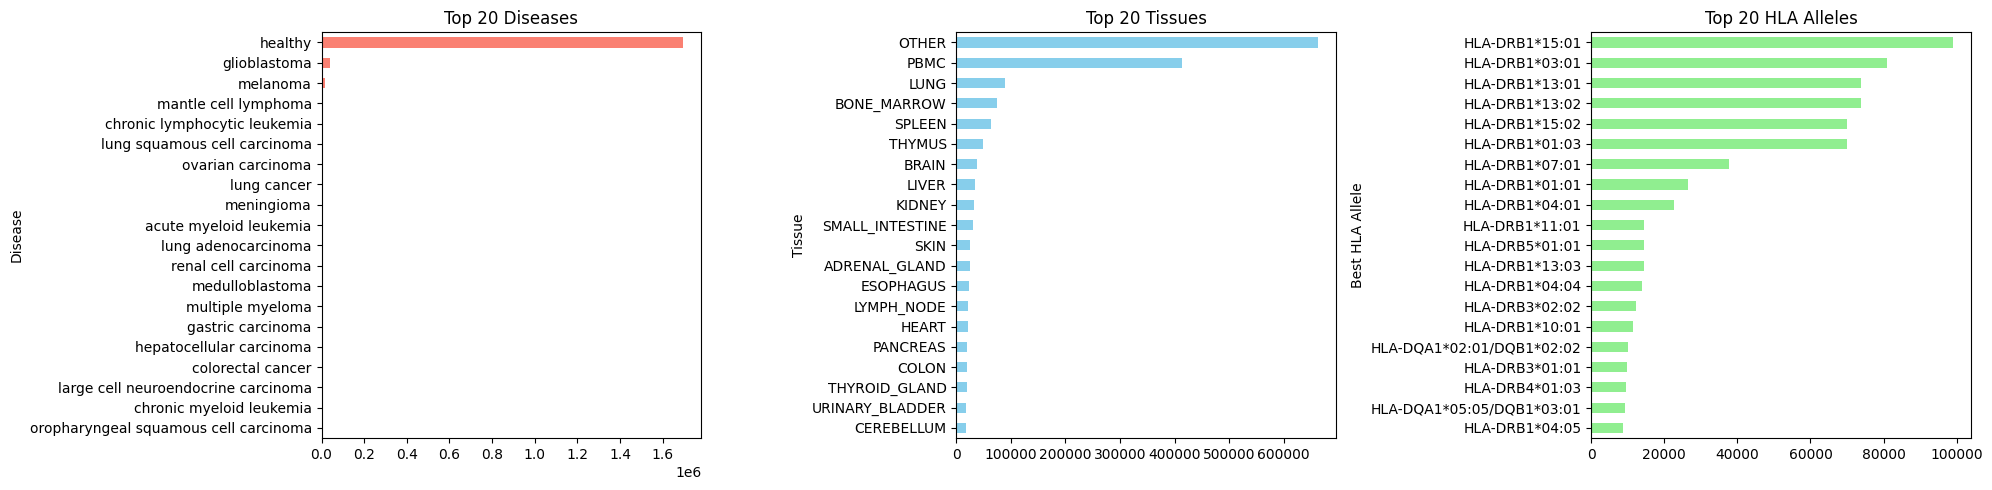

In [5]:
# Quick visual of the three distributions
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
top20_diseases.plot(kind='barh', ax=axes[0], color='salmon').invert_yaxis()
axes[0].set_title('Top 20 Diseases')
top20_tissues.plot(kind='barh', ax=axes[1], color='skyblue').invert_yaxis()
axes[1].set_title('Top 20 Tissues')
top20_alleles.plot(kind='barh', ax=axes[2], color='lightgreen').invert_yaxis()
axes[2].set_title('Top 20 HLA Alleles')
plt.tight_layout(); plt.show()

In [6]:
# ============================================================
# PREPARATION
# ============================================================

# Step 1: basic quality gates (sequence, length window, label)
n0 = len(df)
df = df[df['Peptide Sequence'].notna() & (df['Peptide Sequence'].str.len() > 0)]
df = df[df['Peptide Sequence'].apply(lambda s: all(c in AMINO_ACIDS for c in str(s)))]
df = df[df['length'].between(LENGTH_MIN, LENGTH_MAX)]
df = df[df['is_cancer'].isin([0, 1])]
df['ms_confirmed'] = 1
df = df.reset_index(drop=True)
print(f"Step 1 quality gates: {n0:,} -> {len(df):,}")
print(df['length'].value_counts().sort_index().to_string())

Step 1 quality gates: 1,769,475 -> 1,581,983
length
13    530002
14    154470
15    314913
16    172341
17    126935
18     82668
19     54854
20     49001
21     29985
22     21984
23     16939
24     14427
25     13464


In [7]:
# Step 2: disease whitelist - applied BEFORE HLA filter so we never lose whitelist cancer rows
n_before = len(df)
keep_mask = (df['is_cancer'] == 0) | (df['Disease'].isin(CANCER_WHITELIST))
df = df[keep_mask].reset_index(drop=True)
print(f"Step 2 disease whitelist: {n_before:,} -> {len(df):,}")
print("\nCancer rows per kept disease:")
print(df[df['is_cancer']==1]['Disease'].value_counts().to_string())

Step 2 disease whitelist: 1,581,983 -> 1,581,890

Cancer rows per kept disease:
Disease
glioblastoma                    39286
melanoma                        13316
mantle cell lymphoma             8135
lung squamous cell carcinoma     1086
chronic lymphocytic leukemia      422
ovarian carcinoma                 412
meningioma                        225
acute myeloid leukemia             81


In [8]:
# Step 3: HLA filter - drop missing alleles always, but exempt whitelist cancer from rare-allele cutoff
n_before = len(df)
df = df.dropna(subset=['Best HLA Allele'])
df = df[df['Best HLA Allele'].str.strip() != ""]
allele_counts = df['Best HLA Allele'].value_counts()
valid_alleles = set(allele_counts[allele_counts >= MIN_ROWS_PER_ALLELE].index)
cancer_keep  = df['is_cancer'] == 1
healthy_keep = (df['is_cancer'] == 0) & df['Best HLA Allele'].isin(valid_alleles)
df = df[cancer_keep | healthy_keep].reset_index(drop=True)
print(f"Step 3 HLA filter: {n_before:,} -> {len(df):,}  (healthy-side alleles kept: {len(valid_alleles)})")
print("\nCancer rows surviving (should match Step 2):")
print(df[df['is_cancer']==1]['Disease'].value_counts().to_string())

Step 3 HLA filter: 1,581,890 -> 748,456  (healthy-side alleles kept: 94)

Cancer rows surviving (should match Step 2):
Disease
glioblastoma                    34002
melanoma                            6
chronic lymphocytic leukemia        1


In [ ]:
# Step 4: split by source so IEDB and PCI-DB get separate stratified datasets
df_iedb = df[df['source'] == 'iedb'].copy()
df_pci  = df[df['source'] == 'pci_db'].copy()
print(f"IEDB available:   {len(df_iedb):,}  (cancer={(df_iedb['is_cancer']==1).sum():,}, healthy={(df_iedb['is_cancer']==0).sum():,})")
# print(f"PCI-DB available: {len(df_pci):,}  (cancer={(df_pci['is_cancer']==1).sum():,}, healthy={(df_pci['is_cancer']==0).sum():,})")

IEDB available:   748,456  (cancer=34,009, healthy=714,447)
PCI-DB available: 0  (cancer=0, healthy=0)


In [10]:
# ============================================================
# STRATIFICATION
# Goal: keep every whitelist cancer disease, cap only the over-represented ones
# Healthy is capped at MAX_HEALTHY_RATIO x cancer total; no per-tissue cap
# ============================================================

def stratify_classII(data, big_disease_cap, name):
    df_c = data[data['is_cancer'] == 1].copy()
    df_h = data[data['is_cancer'] == 0].copy()

    # Cancer: take ALL rows for small whitelist diseases, cap only the big ones
    cancer_parts = []
    for disease in CANCER_WHITELIST:
        pool = df_c[df_c['Disease'] == disease]
        if len(pool) == 0: continue
        if len(pool) <= big_disease_cap:
            cancer_parts.append(pool)
        else:
            cancer_parts.append(pool.sample(n=big_disease_cap, random_state=RANDOM_STATE))
    cancer_final = pd.concat(cancer_parts, ignore_index=True) if cancer_parts else pd.DataFrame()

    # Healthy: total cap = MAX_HEALTHY_RATIO x cancer count, water-fill across tissues for variety
    target_healthy = int(len(cancer_final) * MAX_HEALTHY_RATIO)
    if len(df_h) > target_healthy and target_healthy > 0:
        tissue_counts = df_h['Tissue'].value_counts().sort_values()
        remaining = target_healthy
        remaining_tissues = len(tissue_counts)
        healthy_parts = []
        for tissue, count in tissue_counts.items():
            if remaining_tissues <= 0 or remaining <= 0: break
            fair = max(1, remaining // remaining_tissues)
            take = min(count, fair)
            pool = df_h[df_h['Tissue'] == tissue]
            healthy_parts.append(pool if take >= len(pool) else pool.sample(n=take, random_state=RANDOM_STATE))
            remaining -= take
            remaining_tissues -= 1
        healthy_final = pd.concat(healthy_parts, ignore_index=True) if healthy_parts else pd.DataFrame()
        if len(healthy_final) > target_healthy:
            healthy_final = healthy_final.sample(n=target_healthy, random_state=RANDOM_STATE)
    else:
        healthy_final = df_h

    final = pd.concat([cancer_final, healthy_final], ignore_index=True)
    final = final.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    n_c = int((final['is_cancer']==1).sum())
    n_h = int((final['is_cancer']==0).sum())
    ratio = n_h / max(1, n_c)
    print(f"\n--- {name} stratified ---")
    print(f"Total: {len(final):,} | Cancer: {n_c:,} | Healthy: {n_h:,} | H/C ratio: {ratio:.2f} (cap {MAX_HEALTHY_RATIO})")
    print("Diseases (cancer):")
    print(final[final['is_cancer']==1]['Disease'].value_counts().to_string())
    print("Tissues (top 10):")
    print(final['Tissue'].value_counts().head(10).to_string())
    return final

# big_disease_cap=5000 trims glioblastoma/melanoma/mantle_cell_lymphoma while leaving the smaller ones whole
iedb_final = stratify_classII(df_iedb, big_disease_cap=5000, name="IEDB")


--- IEDB stratified ---
Total: 11,015 | Cancer: 5,007 | Healthy: 6,008 | H/C ratio: 1.20 (cap 1.2)
Diseases (cancer):
Disease
glioblastoma                    5000
melanoma                           6
chronic lymphocytic leukemia       1
Tissues (top 10):
Tissue
BRAIN          3536
OTHER          1893
SKIN            221
LYMPH_NODE      216
THYMUS          215
BONE_MARROW     215
LUNG            215
ESOPHAGUS       215
SPLEEN          215
PBMC            215


In [11]:
# Save per-source ML-ready intermediate files (still with text columns for traceability)
IEDB_PATH.parent.mkdir(parents=True, exist_ok=True)
iedb_final.to_csv(IEDB_PATH, index=False)
# pci_final.to_csv(PCI_PATH, index=False)
print(f"Saved IEDB:  {IEDB_PATH}  ({len(iedb_final):,} rows)")
# print(f"Saved PCI:   {PCI_PATH}   ({len(pci_final):,} rows)")

Saved IEDB:  /Users/shubhaychoubey/Documents/GitHub/Peptide/Notebooks/Data/MLready/IEDB_classII_ML_ready.csv  (11,015 rows)


In [12]:
# ============================================================
# FINAL ML-READY PREP (mirrors Data_Testing1 for class I)
# ============================================================

# Combine sources into one ML-ready dataset
ml = pd.concat([iedb_final], ignore_index=True)
n0 = len(ml)
print(f"Combined: {n0:,} rows x {len(ml.columns)} columns")

Combined: 11,015 rows x 75 columns


In [13]:
# Drop zero-variance / high-missing columns
DROP_ZERO_VAR = ["has_modification", "oxidation_flag"]
ml = ml.drop(columns=[c for c in DROP_ZERO_VAR if c in ml.columns])

if "flexibility_mean" in ml.columns:
    pct_missing = ml["flexibility_mean"].isnull().mean() * 100
    ml = ml.drop(columns=["flexibility_mean"])
    print(f"Dropped flexibility_mean ({pct_missing:.1f}% missing)")

Dropped flexibility_mean (0.0% missing)


In [14]:
# Rescale aa_pct_* to 0-1 if they are 0-100
AA_COLS = [f"aa_pct_{aa}" for aa in "ACDEFGHIKLMNPQRSTVWY"]
present_aa = [c for c in AA_COLS if c in ml.columns]
if present_aa:
    sample_max = ml[present_aa].max().max()
    if sample_max > 1.5:
        ml[present_aa] = ml[present_aa] / 100.0
        print(f"Scaled {len(present_aa)} aa_pct_* columns to 0-1 (was 0-{sample_max:.1f})")
    else:
        print("aa_pct_* already 0-1 - skipping")

Scaled 20 aa_pct_* columns to 0-1 (was 0-66.7)


In [15]:
# Clip outliers on unstable indices
CLIP_COLS = ["instability_index", "aliphatic_index"]
for col in CLIP_COLS:
    if col in ml.columns:
        cap = ml[col].quantile(0.99)
        n_clipped = (ml[col] > cap).sum()
        ml[col] = ml[col].clip(upper=cap)
        print(f"Clipped {col} at 99% ({cap:.2f}) - affected {n_clipped:,} rows")

Clipped instability_index at 99% (136.30) - affected 110 rows
Clipped aliphatic_index at 99% (162.67) - affected 105 rows


In [16]:
# Exact duplicate removal on (sequence, tissue, label)
n_before = len(ml)
ml = ml.drop_duplicates(subset=["Peptide Sequence", "Tissue", "is_cancer"])
print(f"Removed {n_before-len(ml):,} duplicates -> {len(ml):,} rows")

Removed 40 duplicates -> 10,975 rows


In [17]:
# Found-in-healthy leakage flag
healthy_seqs = set(ml.loc[ml['is_cancer'] == 0, 'Peptide Sequence'])
ml['found_in_healthy'] = ml['Peptide Sequence'].isin(healthy_seqs).astype(int)
cancer_overlap = ((ml['is_cancer']==1) & (ml['found_in_healthy']==1)).sum()
print(f"Cancer rows also seen in healthy tissue: {cancer_overlap:,}")

Cancer rows also seen in healthy tissue: 160


In [18]:
# Stratification key for downstream train/val splits
ml['strat_key'] = ml['is_cancer'].astype(int).astype(str) + "_" + ml['length'].astype(str)
print("strat_key distribution:")
for k, c in ml['strat_key'].value_counts().sort_index().items():
    print(f"  {k}: {c:,}")

strat_key distribution:
  0_13: 653
  0_14: 977
  0_15: 1,288
  0_16: 1,180
  0_17: 818
  0_18: 473
  0_19: 234
  0_20: 118
  0_21: 66
  0_22: 56
  0_23: 43
  0_24: 42
  0_25: 29
  1_13: 354
  1_14: 665
  1_15: 903
  1_16: 933
  1_17: 817
  1_18: 507
  1_19: 357
  1_20: 217
  1_21: 147
  1_22: 98


In [ ]:
# # Drop identifier / text / leakage columns to make pure numeric ML-ready frame
# DROP_FINAL = [
#     'ID', 'Uniprot IDs', 'MHC Class', 'Peptide Modifications',
#     'hla_source', 'feature_error', 'hla_known', 'Affinity % Rank',
#     'affinity_bin', 'is_strong_binder', 'is_weak_binder', 'is_non_binder',
#     'n_term_residue', 'c_term_residue', 'anchor_pos_2', 'anchor_pos_C',
#     'anchor_p2_hydro', 'anchor_pC_hydro', 'blosum62_p2', 'blosum62_pC',
#     'hydrophobic_residue_count', 'aromatic_residue_count', 'tryptophan_count',
#     'is_9mer', 'length_class', 'ms_confirmed',
#     'Peptide Sequence', 'Best HLA Allele', 'source',
#     'hla_population_freq', 'found_in_healthy', 'strat_key'
# ]
# ml = ml.drop(columns=[c for c in DROP_FINAL if c in ml.columns], errors='ignore')
# ml = ml.loc[:, ~ml.columns.duplicated()]
# print(f"Final columns ({len(ml.columns)}): {list(ml.columns)}")

Final columns (41): ['Tissue', 'length', 'molecular_weight', 'charge_pH_7', 'hydrophobicity_GRAVY', 'isoelectric_point', 'aromaticity', 'instability_index', 'helix_fraction', 'sheet_fraction', 'turn_fraction', 'aliphatic_index', 'boman_index', 'tcr_contact_hydro_mean', 'tcr_aromatic_count', 'tcr_hydrophobic_count', 'has_tryptophan', 'tryptophan_at_tcr_pos', 'hydrophobic_fraction', 'has_aromatic_central', 'aa_pct_A', 'aa_pct_C', 'aa_pct_D', 'aa_pct_E', 'aa_pct_F', 'aa_pct_G', 'aa_pct_H', 'aa_pct_I', 'aa_pct_K', 'aa_pct_L', 'aa_pct_M', 'aa_pct_N', 'aa_pct_P', 'aa_pct_Q', 'aa_pct_R', 'aa_pct_S', 'aa_pct_T', 'aa_pct_V', 'aa_pct_W', 'aa_pct_Y', 'is_cancer']


In [19]:
# ============================================================
# QUALITY TESTING
# ============================================================

print("Final shape:", ml.shape)
print("\nLabel balance:")
vc = ml['is_cancer'].value_counts().sort_index()
for label, count in vc.items():
    tag = 'healthy' if label == 0 else 'cancer '
    print(f"  {tag} ({int(label)}): {count:,}  ({100*count/len(ml):.1f}%)")

print("\nLength distribution:")
for length, count in ml['length'].value_counts().sort_index().items():
    cancer = (ml[ml['length']==length]['is_cancer']==1).sum()
    healthy = count - cancer
    print(f"  {length}-mer: {count:,} total  (cancer={cancer:,}, healthy={healthy:,})")

print("\nNaN counts per column (non-zero only):")
nans = ml.isna().sum()
print(nans[nans>0].to_string() if (nans>0).any() else "  none")

if 'aa_pct_A' in ml.columns:
    print(f"\naa_pct_A range check: max={ml['aa_pct_A'].max():.4f} (target <= 1.0)")

Final shape: (10975, 74)

Label balance:
  healthy (0): 5,977  (54.5%)
  cancer  (1): 4,998  (45.5%)

Length distribution:
  13-mer: 1,007 total  (cancer=354, healthy=653)
  14-mer: 1,642 total  (cancer=665, healthy=977)
  15-mer: 2,191 total  (cancer=903, healthy=1,288)
  16-mer: 2,113 total  (cancer=933, healthy=1,180)
  17-mer: 1,635 total  (cancer=817, healthy=818)
  18-mer: 980 total  (cancer=507, healthy=473)
  19-mer: 591 total  (cancer=357, healthy=234)
  20-mer: 335 total  (cancer=217, healthy=118)
  21-mer: 213 total  (cancer=147, healthy=66)
  22-mer: 154 total  (cancer=98, healthy=56)
  23-mer: 43 total  (cancer=0, healthy=43)
  24-mer: 42 total  (cancer=0, healthy=42)
  25-mer: 29 total  (cancer=0, healthy=29)

NaN counts per column (non-zero only):
Peptide Modifications    10975
Uniprot IDs                585
Affinity % Rank          10975
feature_error            10975
hla_population_freq       7014

aa_pct_A range check: max=0.6429 (target <= 1.0)


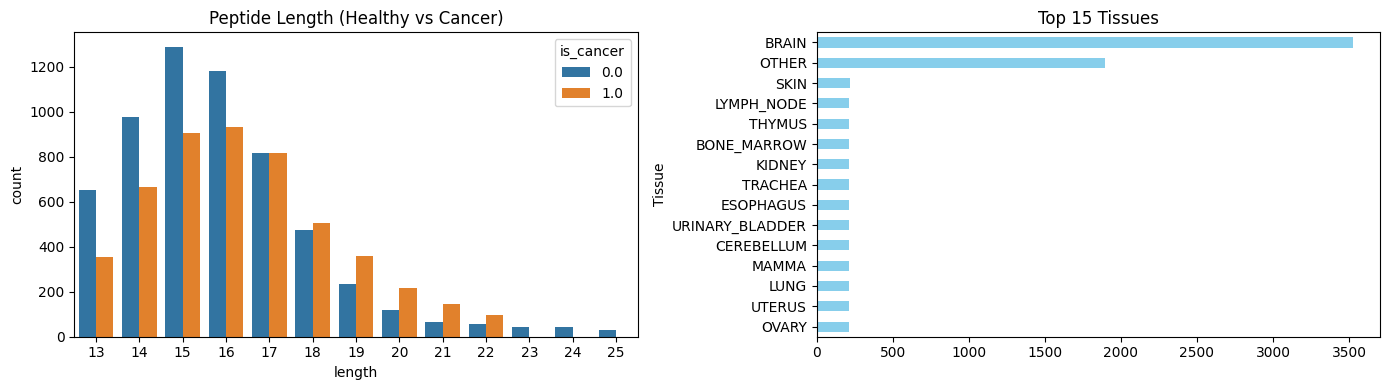

In [20]:
# Visual sanity checks
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=ml, x='length', hue='is_cancer', palette=['#1f77b4','#ff7f0e'], ax=axes[0])
axes[0].set_title('Peptide Length (Healthy vs Cancer)')
ml['Tissue'].value_counts().head(15).plot(kind='barh', color='skyblue', ax=axes[1])
axes[1].invert_yaxis(); axes[1].set_title('Top 15 Tissues')
plt.tight_layout(); plt.show()

In [21]:
# Save final class II ML-ready CSV
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
ml.to_csv(OUTPUT_PATH)
print(f"Saved {len(ml):,} rows x {len(ml.columns)} columns -> {OUTPUT_PATH}")

Saved 10,975 rows x 74 columns -> /Users/shubhaychoubey/Documents/GitHub/Peptide/Data/ML_Ready/mhc_class_II.csv
